In [1]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
plt.style.use('default')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Load data
url = "https://raw.githubusercontent.com/diplomadoequipo908-a11y/Proyecto-modulo-5/main/dataset.csv"
raw = pd.read_csv(url)
raw = raw.drop(columns=['Unnamed: 0'])
# Drop duplicates on track_id keep unique tracks.
df = raw.drop_duplicates(subset='track_id').copy().reset_index(drop=True)
print('Raw data:',raw.shape)
print('Unique tracks data:',df.shape)
df.describe()

Raw data: (114000, 20)
Unique tracks data: (89741, 20)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,33.198438,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,20.580824,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Data Dictionary
| Column | Type | Range | Description |
|---|---|---|---|
| `track_id` | String | — | Unique Spotify URI identifier for the track |
| `artists` | String | — | Performing artist name(s) |
| `album_name` | String | — | Album the track belongs to |
| `track_name` | String | — | Title of the track |
| `popularity` | Integer | 0 – 100 | Spotify popularity score (higher = more popular) |
| `duration_ms` | Integer | 0 – 5.2M | Track duration in milliseconds |
| `explicit` | Boolean | True/False | Whether the track has explicit lyrics |
| `danceability` | Float | 0.0 – 1.0 | How suitable a track is for dancing |
| `energy` | Float | 0.0 – 1.0 | Perceptual measure of intensity and activity |
| `key` | Integer | 0 – 11 | Musical key (0=C, 1=C♯, 2=D … 11=B) |
| `loudness` | Float | -49.5 – 4.5 | Overall loudness in decibels (dB) |
| `mode` | Integer | 0 or 1 | Modality — 1 = Major, 0 = Minor |
| `speechiness` | Float | 0.0 – 1.0 | Presence of spoken words in the track |
| `acousticness` | Float | 0.0 – 1.0 | Confidence the track is acoustic |
| `instrumentalness` | Float | 0.0 – 1.0 | Predicts whether a track has no vocals |
| `liveness` | Float | 0.0 – 1.0 | Detects presence of a live audience |
| `valence` | Float | 0.0 – 1.0 | Musical positiveness conveyed by the track |
| `tempo` | Float | 0 – 243 | Estimated tempo in beats per minute (BPM) |
| `time_signature` | Integer | 0 – 5 | Estimated time signature of the track |
| `track_genre` | String | 114 classes | Genre label assigned to the track |

## Null values

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


artists             1
album_name          1
track_name          1
track_id            0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


In [4]:
# Fill null values
for col in ['track_name', 'album_name', 'artists']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


# Exploratory Data Analysis
## Popularity distribution

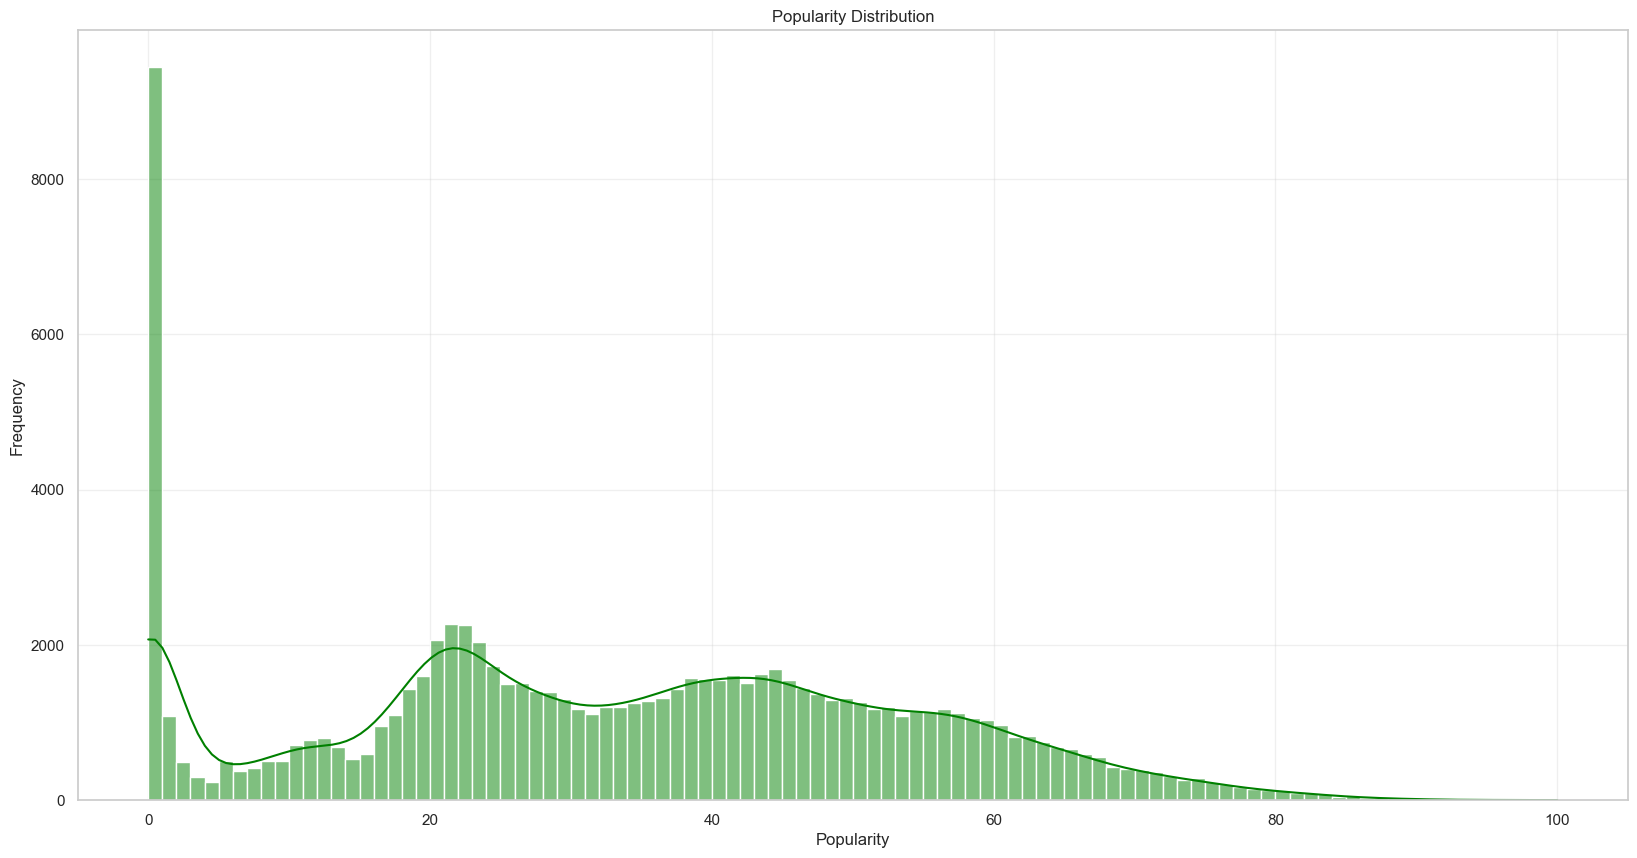

In [5]:
plt.figure(figsize=(20,10))
sns.histplot(df['popularity'], bins=100, kde=True,color='green')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [6]:
print(f"Mean: {df['popularity'].mean():.2f}")
print(f"Median: {df['popularity'].median():.2f}")
print(f"Skewness: {skew(df['popularity']):.3f}")

Mean: 33.20
Median: 33.00
Skewness: 0.071


##### Popularity is approximately symmetric and not dominated by extreme values

#### Popular vs unpopular songs

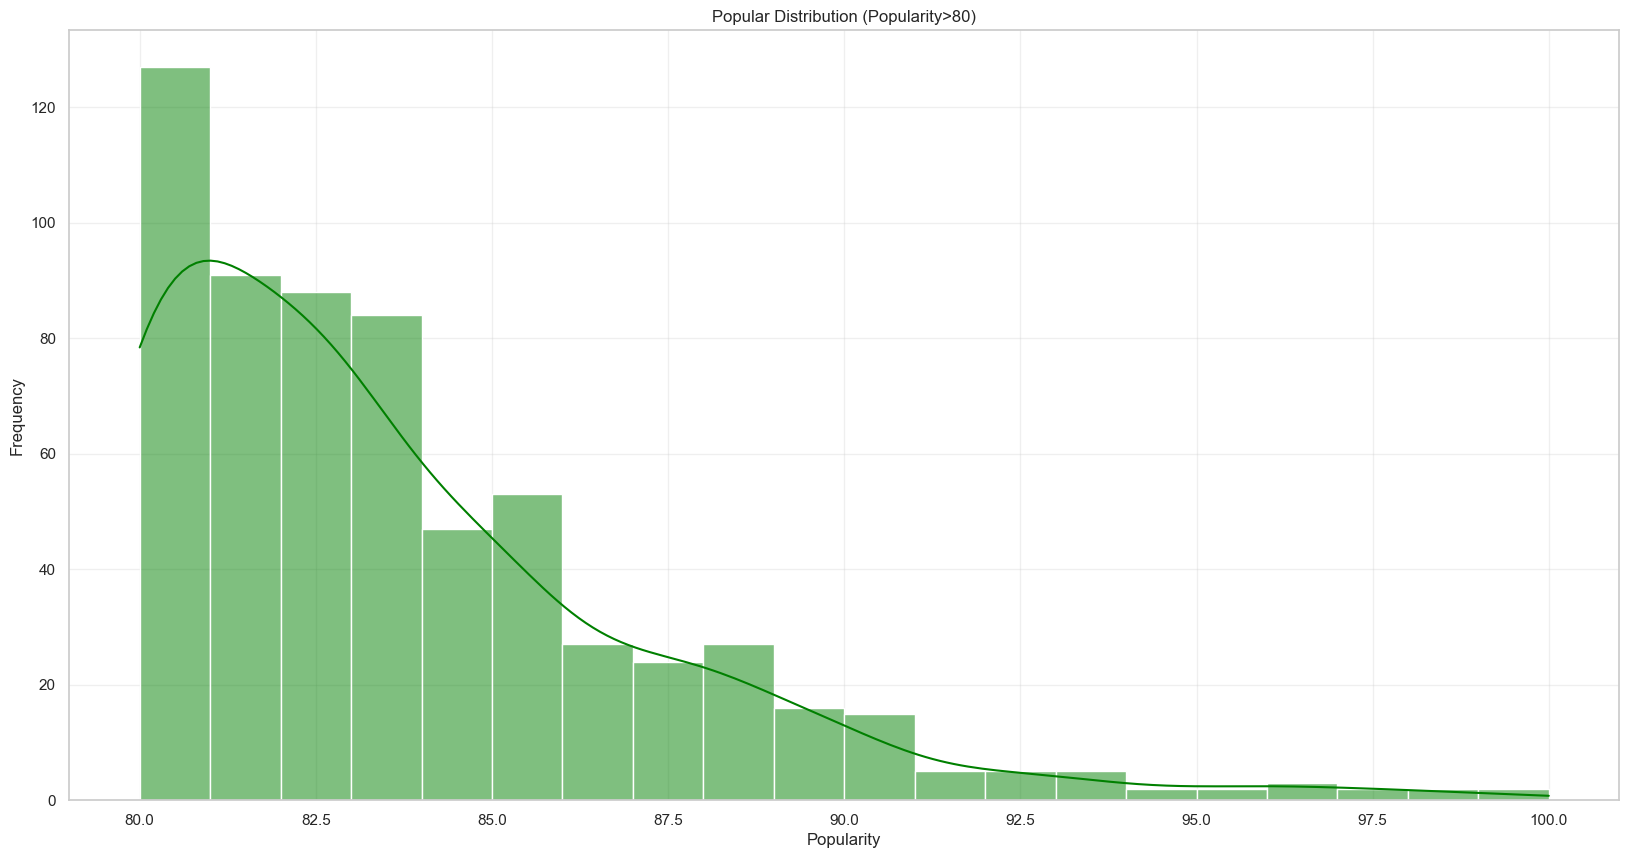

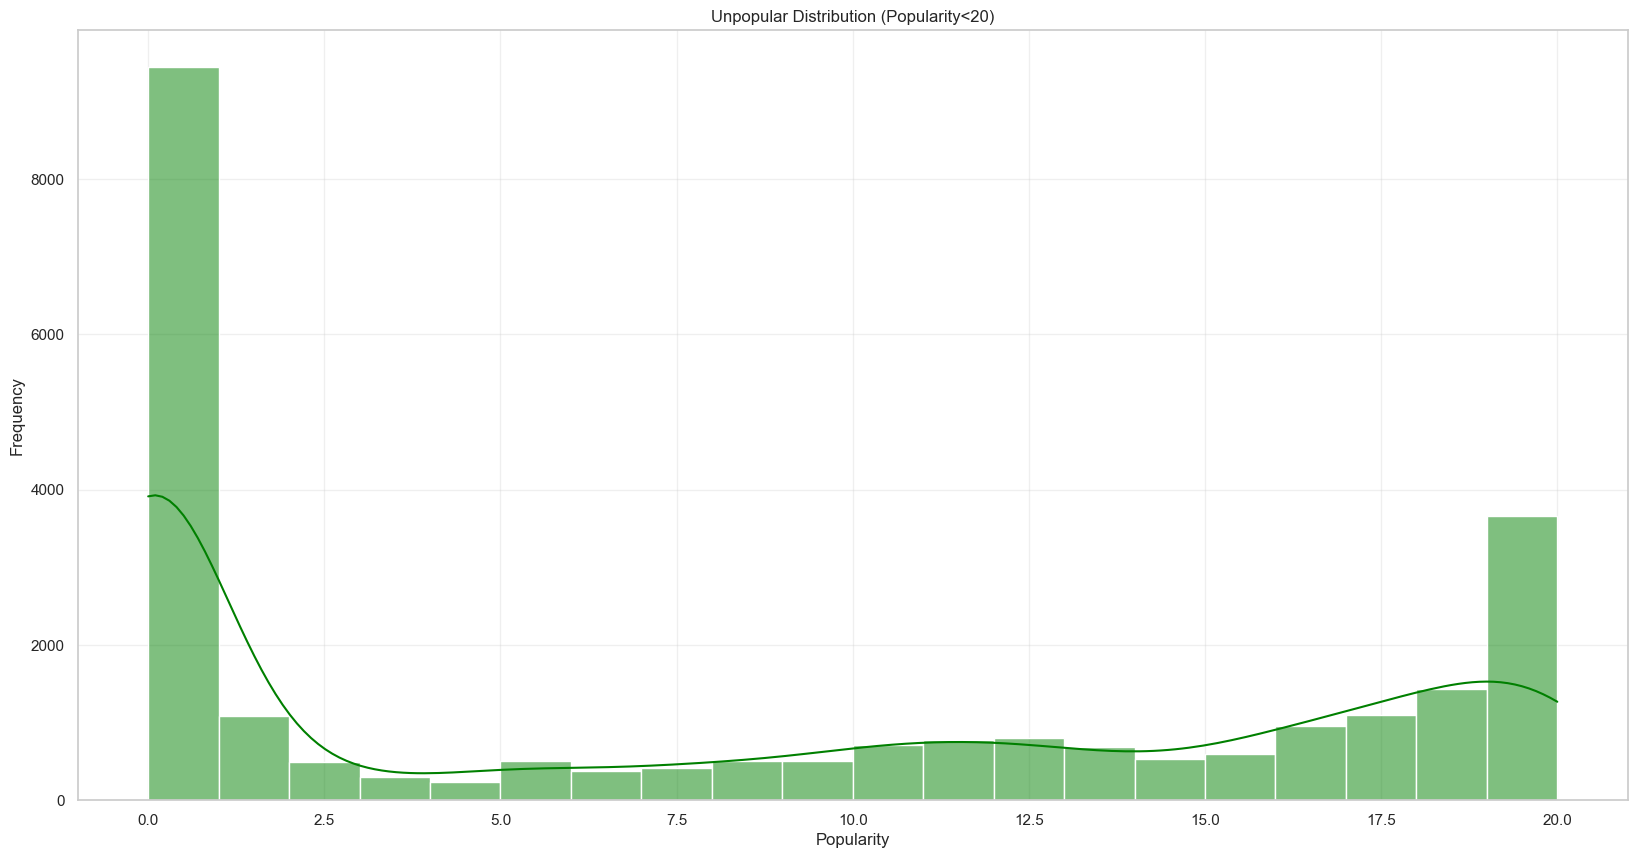

In [7]:
popular = df[df['popularity'] >= 80]

unpopular = df[df['popularity'] <= 20]

plt.figure(figsize=(20,10))
sns.histplot(popular['popularity'], bins=20, kde=True,color='green')
plt.title('Popular Distribution (Popularity>80)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(20,10))
sns.histplot(unpopular['popularity'], bins=20, kde=True,color='green')
plt.title('Unpopular Distribution (Popularity<20)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

## Top 20 genres

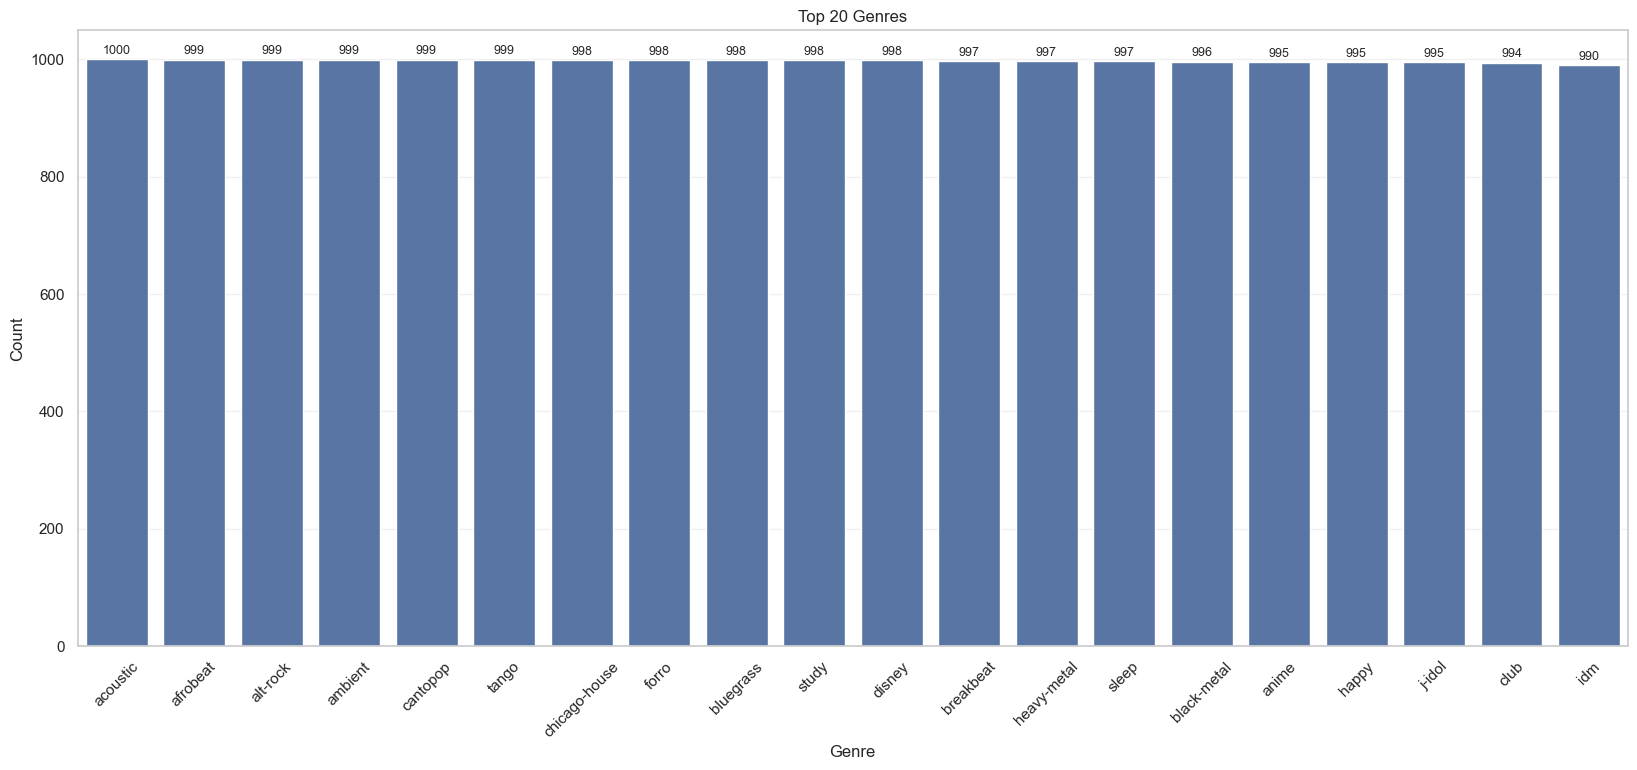

In [8]:
plt.figure(figsize=(20,8))
top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
)
ax = sns.barplot(x=top_genres.index,y=top_genres.values)

for i, v in enumerate(top_genres.values):
    ax.text(
        i,
        v + 10,
        str(v),
        ha='center',
        fontsize=9
    )

plt.title("Top 20 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Average popularity by genres

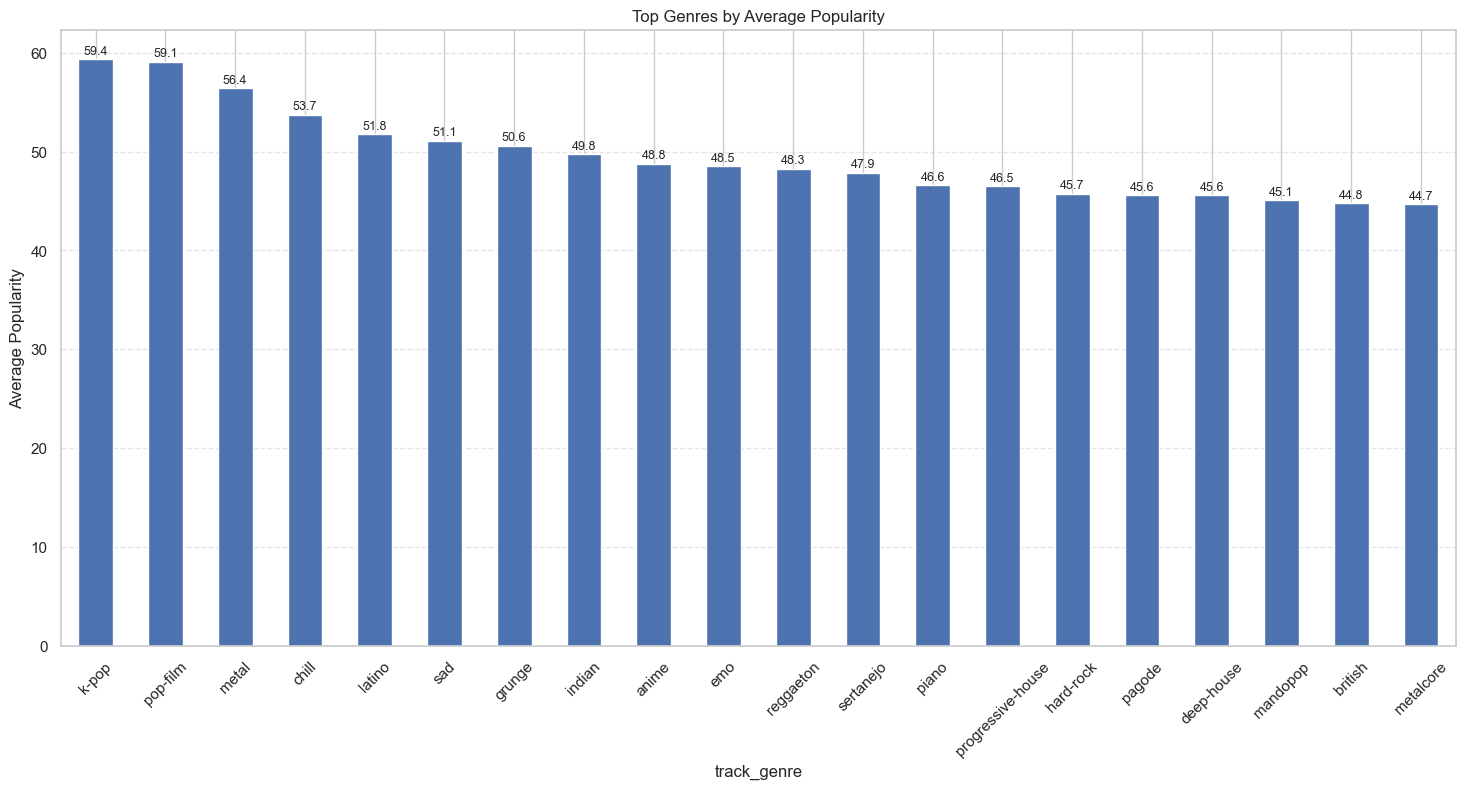

In [9]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
)

top_20 = genre_popularity.head(20)

plt.figure(figsize=(18,8))
ax = top_20.plot(kind='bar')
for i, v in enumerate(top_20.values):
    ax.text(
        i,
        v + 0.5,
        f'{v:.1f}',
        ha='center',
        fontsize=9
    )
plt.title("Top Genres by Average Popularity")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)
plt.show()

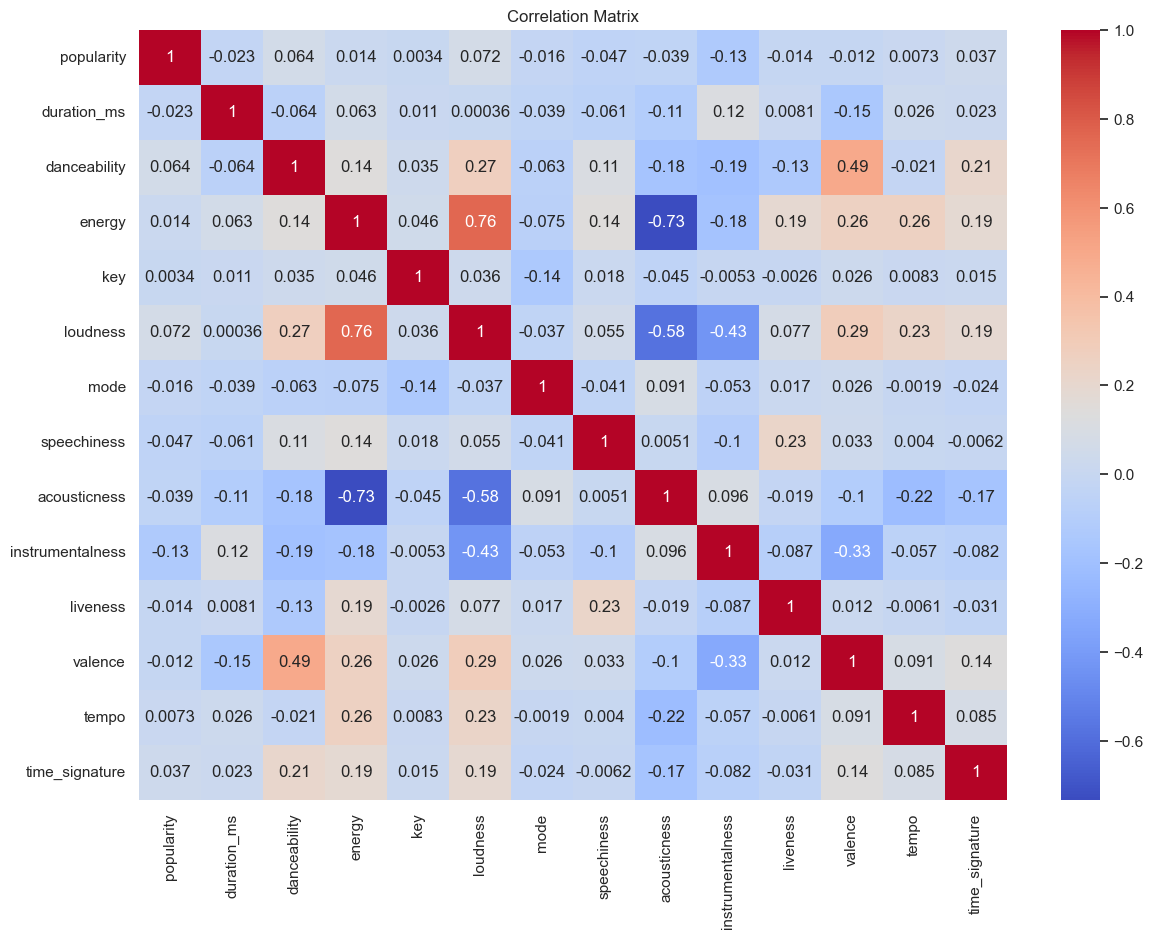

In [10]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

## Correlation with Popularity (Linear)

loudness            0.071676
danceability        0.064281
time_signature      0.036893
energy              0.013728
tempo               0.007270
key                 0.003432
valence            -0.011526
liveness           -0.013844
mode               -0.016214
duration_ms        -0.023119
acousticness       -0.038847
speechiness        -0.047081
instrumentalness   -0.127465
Name: popularity, dtype: float64


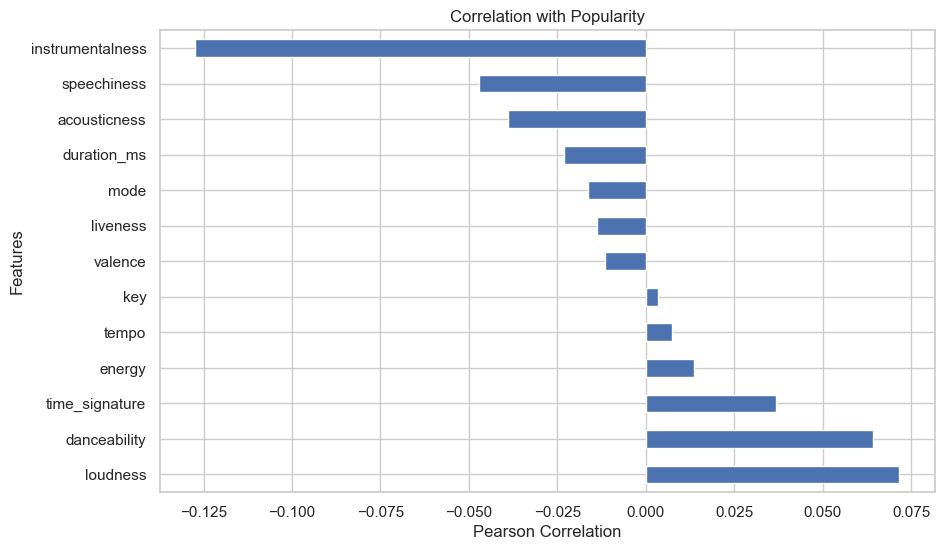

In [11]:
corr_popularity = (
    df.select_dtypes(include=np.number)
      .corr()['popularity']
      .drop('popularity')
      .sort_values(ascending=False)
)

print(corr_popularity)

plt.figure(figsize=(10,6))
corr_popularity.plot(kind='barh')
plt.title("Correlation with Popularity")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.show()

##### We can observe that there are no linear audio characteristics correlations with popularity. These findings suggest that popularity is likely driven by complex interactions among multiple audio characteristics and genre-specific effects. Consequently, a nonlinear modeling approach such as a Multilayer Perceptron (MLP) may be better suited to capture these relationships than traditional linear models.

In [12]:
#df['is_niche'] = (df['popularity'] <= 20)

# counts = df['is_niche'].value_counts()

# labels = [
#     'Non-Niche Songs',
#     'Niche Songs'
# ]

# plt.figure(figsize=(8,8))

# plt.pie(
#     counts.values,
#     labels=labels,
#     autopct='%1.1f%%',
#     startangle=90
# )

# plt.title(
#     "Distribution of Niche vs Non-Niche Songs",
#     fontsize=16,
#     fontweight='bold'
# )

# plt.show()


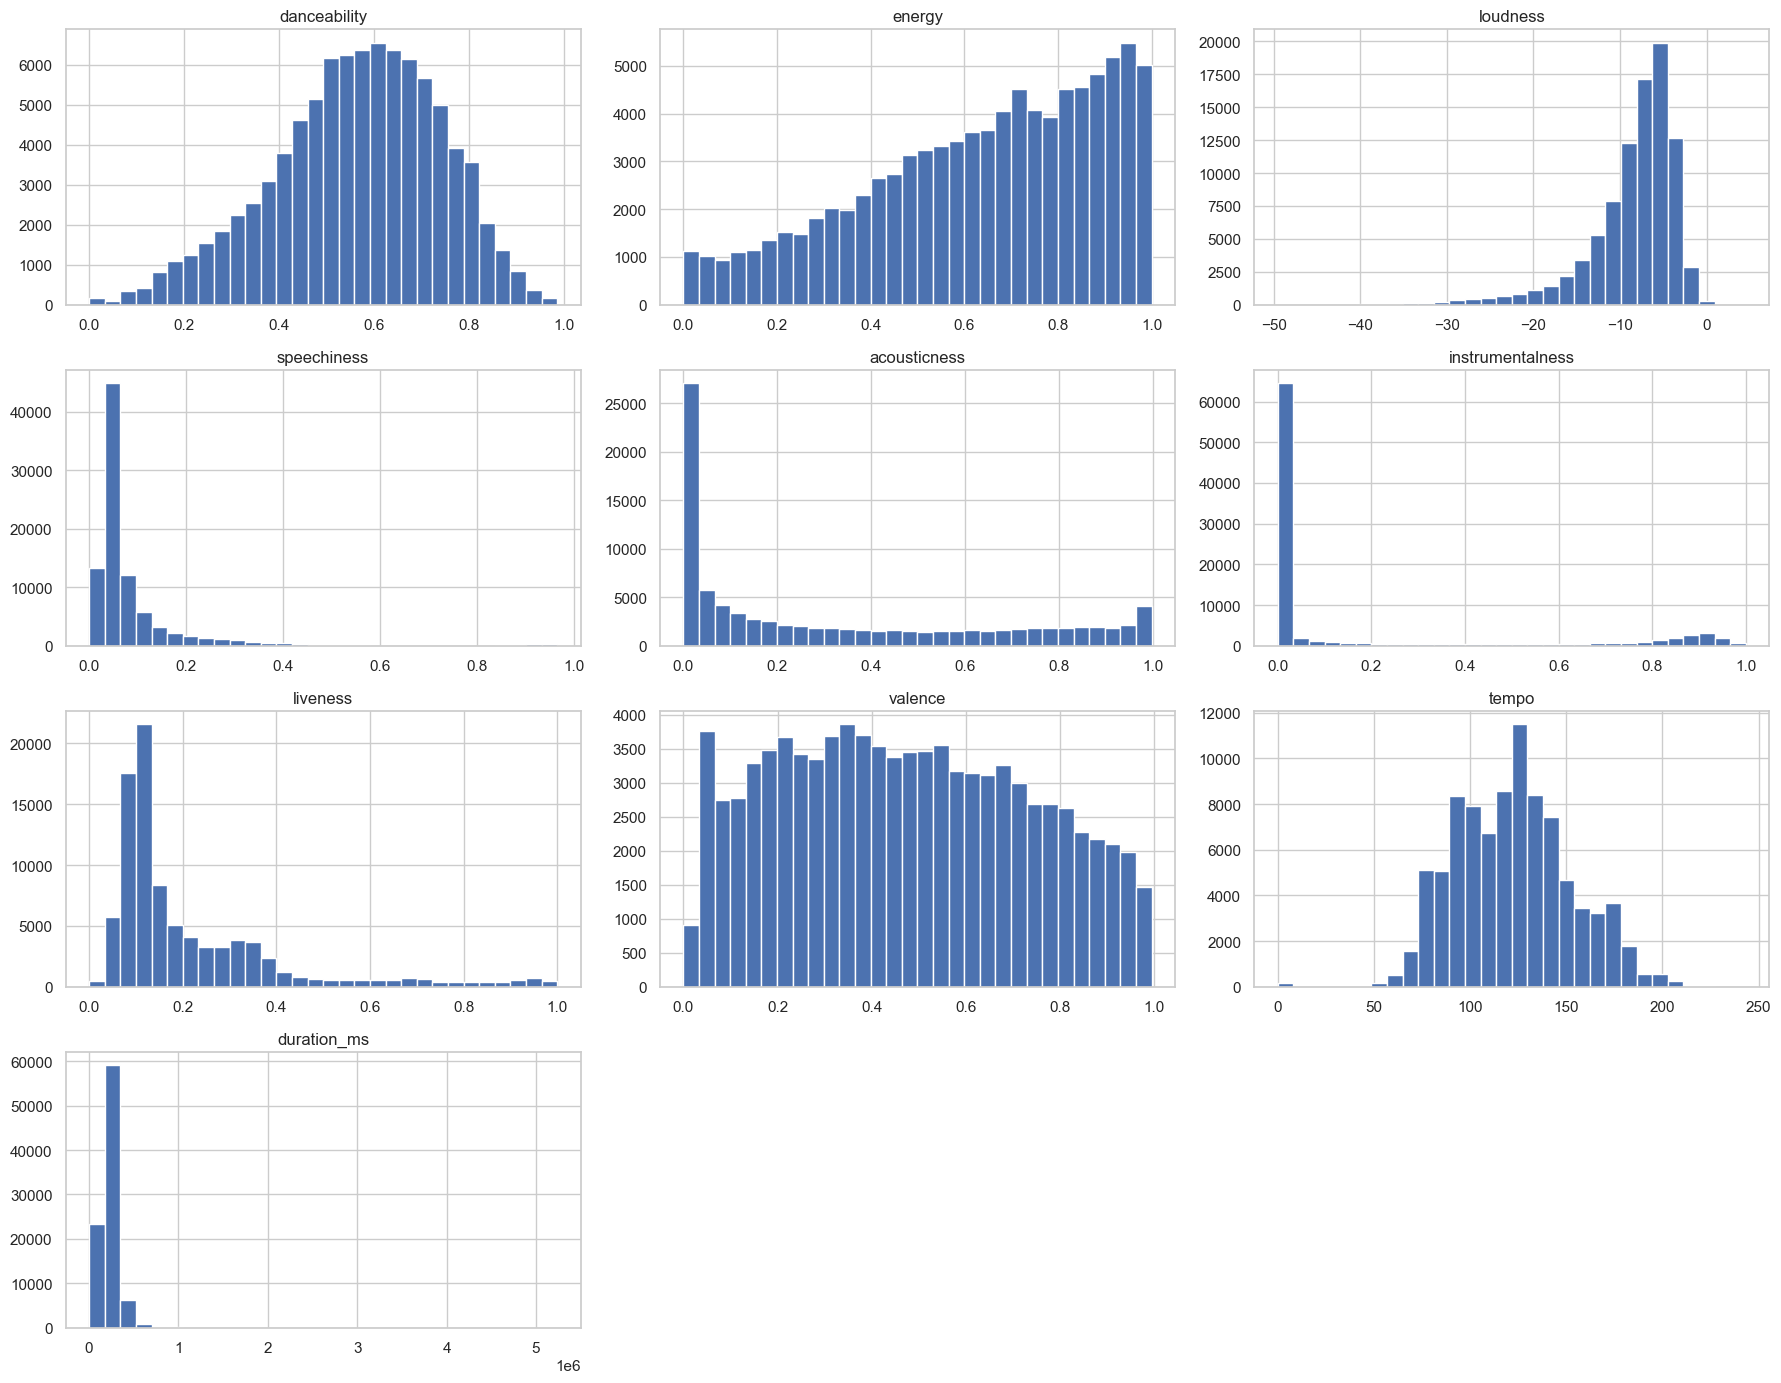

In [13]:
numeric_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

df[numeric_features].hist(
    bins=30,
    figsize=(18,14)
)

plt.tight_layout()

plt.show()

## Linear regression and Ridge, Lasso and ElasticNet

        Model        MAE       RMSE        R2
0      Linear  11.994063  16.848371  0.320388
1       Ridge  11.997763  16.847883  0.320427
2       Lasso  12.198481  16.868165  0.318790
3  ElasticNet  13.286043  17.341489  0.280024


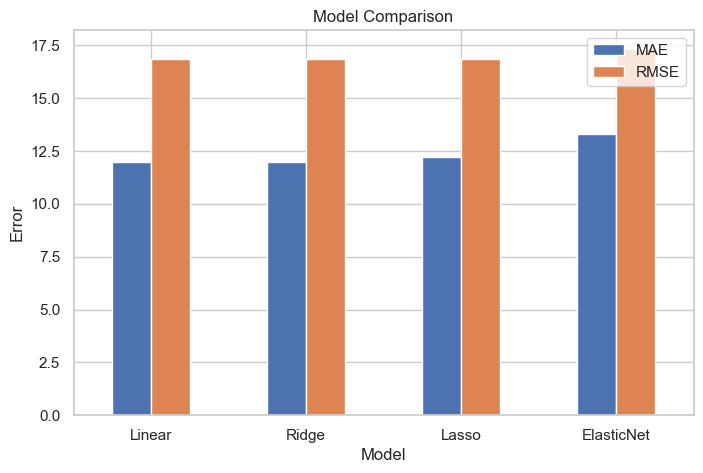

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


df_model = df.drop(columns=[
    'track_id',
    'track_name',
    'album_name',
    'artists',
    'time_signature'
])

df_model['explicit'] = df_model['explicit'].astype(int)
df_model['key'] = df_model['key'].astype(str)
# Log transform due to high skewed distribution.
df_model['duration_ms'] = np.log1p(df_model['duration_ms'])

X = df_model.drop('popularity', axis=1)
y = df_model['popularity']

num_features = [
    'duration_ms','danceability','energy','loudness',
    'speechiness','acousticness','instrumentalness',
    'liveness','valence','tempo'
]

cat_features = ['key','track_genre']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

# Models

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1),
    'Lasso': Lasso(alpha=0.01, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    results.append({
        'Model': name,
        'MAE': mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2': r2_score(y_test, preds)
    })

results = pd.DataFrame(results).sort_values('MAE')

print(results)

# Plot

results.set_index('Model')[['MAE','RMSE']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Comparison')
plt.ylabel('Error')
plt.xticks(rotation=0)
plt.show()

# Best model coefficients

best_name = results.iloc[0]['Model']
best_model = models[best_name]

best_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', best_model)
])

best_pipe.fit(X_train, y_train);



##### From the analysis, acoustic features alone have limited ability to explain song popularity. The correlation matrix shows that all relationships between individual features and popularity are very weak, which indicates that popularity is not driven by any single measurable audio characteristic. 
##### Across the models tested, Ridge regression consistently performed slightly better than Lasso and ElasticNet. This outcome aligns with the structure of the data, where many features are strongly correlated with each other. Ridge handles this multicollinearity more effectively by distributing importance across correlated variables, rather than eliminating them as Lasso does. ElasticNet, which combines both approaches, did not provide additional benefit in this case.
##### Feature engineering, including interaction terms and nonlinear transformations, resulted in only marginal improvements. This suggests that the limitation is not the absence of simple transformations, but rather that the relationship between the inputs and the target is inherently complex. Linear models, even when enhanced, are reaching their performance limit on this dataset.
##### The overall performance, with an R² of around 0.22, indicates that a large portion of the variability in popularity remains unexplained. This is expected, as popularity is influenced by many external factors that are not present in the dataset, such as artist recognition, marketing, timing, and exposure.
##### At this stage, further tuning of linear models or additional feature engineering is unlikely to produce meaningful improvements. The results indicate that the problem is not under-optimized, but under-modeled. The next logical step is to move toward more flexible nonlinear models, such as gradient boosting or neural networks, which are better suited to capture complex interactions and patterns in this type of data.

### XGBoost

In [18]:
import pandas as pd
from itertools import product

from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, r2_score

preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)],
    remainder='passthrough'
)

X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)
X_test_enc = preprocessor.transform(X_test)

results = []

for max_depth, learning_rate in product(
    [4, 6, 8],
    [0.03, 0.05, 0.10]
):

    model = XGBRegressor(
        objective='reg:squarederror',
        eval_metric='mae',
        n_estimators=5000,
        max_depth=max_depth,
        learning_rate=learning_rate,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1,
        reg_alpha=0,
        early_stopping_rounds=30,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train_enc,
        y_train,
        eval_set=[(X_val_enc, y_val)],
        verbose=False
    )

    val_preds = model.predict(X_val_enc)
    test_preds = model.predict(X_test_enc)

    results.append({
        'max_depth': max_depth,
        'learning_rate': learning_rate,
        'best_iteration': model.best_iteration,
        'MAE_val': mean_absolute_error(y_val, val_preds),
        'R2_val': r2_score(y_val, val_preds),
        'MAE_test': mean_absolute_error(y_test, test_preds),
        'R2_test': r2_score(y_test, test_preds)
    })

results_df = pd.DataFrame(results).sort_values('MAE_test')

print("\n=== XGBOOST HYPERPARAMETER COMPARISON ===")
print(results_df)

best_params = results_df.iloc[0]

print("\n=== BEST CONFIGURATION ===")
print(best_params)

best_model = XGBRegressor(
    objective='reg:squarederror',
    eval_metric='mae',
    n_estimators=5000,
    max_depth=int(best_params['max_depth']),
    learning_rate=float(best_params['learning_rate']),
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1,
    reg_alpha=0,
    early_stopping_rounds=30,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

best_model.fit(
    X_train_enc,
    y_train,
    eval_set=[(X_val_enc, y_val)],
    verbose=False
)

test_preds = best_model.predict(X_test_enc)

print("\n=== FINAL MODEL PERFORMANCE ===")
print(f"Best Iteration: {best_model.best_iteration}")
print(f"MAE Test: {mean_absolute_error(y_test, test_preds):.4f}")
print(f"R² Test: {r2_score(y_test, test_preds):.4f}")


=== XGBOOST HYPERPARAMETER COMPARISON ===
   max_depth  learning_rate  best_iteration    MAE_val    R2_val   MAE_test  \
6          8           0.03            3402  10.051738  0.453849  10.016058   
7          8           0.05            1946  10.099876  0.450622  10.070462   
8          8           0.10             934  10.199470  0.443156  10.178032   
4          6           0.05            2462  10.253890  0.449012  10.265630   
3          6           0.03            3280  10.320601  0.450027  10.294111   
5          6           0.10            1009  10.397502  0.443591  10.386754   
2          4           0.10            1834  10.640850  0.427202  10.622811   
0          4           0.03            4998  10.660350  0.431445  10.632180   
1          4           0.05            3131  10.660699  0.430141  10.638632   

    R2_test  
6  0.453810  
7  0.449291  
8  0.440682  
4  0.445848  
3  0.451401  
5  0.442469  
2  0.427564  
0  0.433119  
1  0.429938  

=== BEST CONFIGURATION ==